In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv("AB_NYC_2019.csv")

In [3]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
df.shape

(48895, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [7]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [11]:
missing = df.isnull().sum()
missing

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

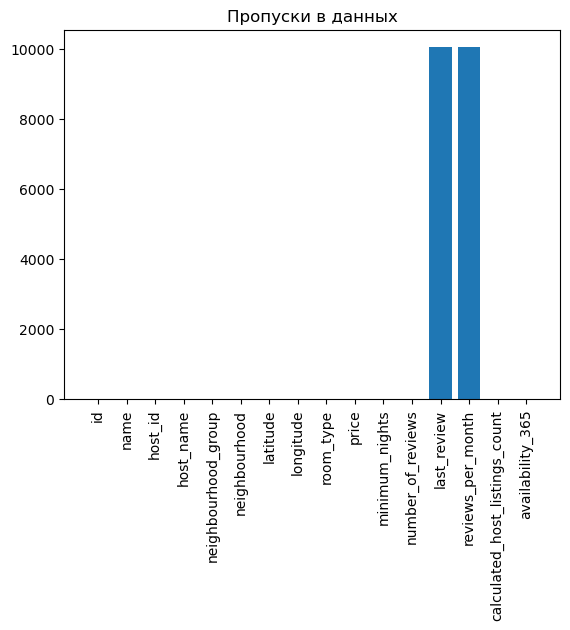

In [15]:
plt.figure()
plt.bar(missing.index,missing.values)

plt.title("Пропуски в данных")
plt.xticks(rotation=90)
plt.show()

In [16]:
df["name"] = df["name"].fillna("Airbnb listing")

In [17]:
df["host_name"] = df["host_name"].fillna("Unknown host")

In [20]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48895 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [28]:
price_by_room = df.groupby("room_type")["price"].mean()

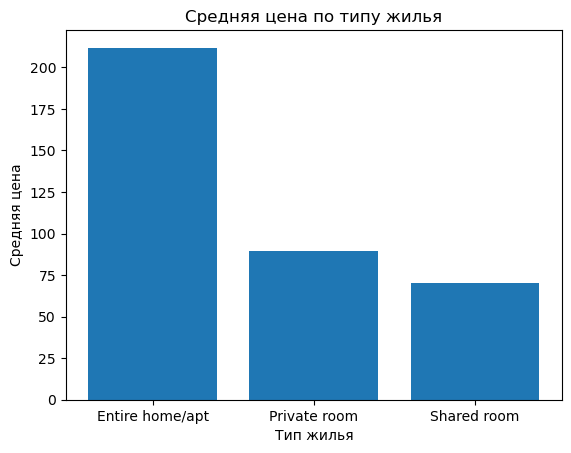

In [29]:
plt.figure()
plt.bar(price_by_room.index, price_by_room.values)

plt.title("Средняя цена по типу жилья")
plt.xlabel("Тип жилья")
plt.ylabel("Средняя цена")
plt.xticks(rotation = 0)
plt.show()

In [ ]:
По данному графику можно увидеть среднюю цену по типу жилья, также можно проанализировать, какие типы жилья дороже и какова разница между категориями  

In [35]:
price_by_neighbourhood_group = df.groupby("neighbourhood_group")["price"].mean()
price_by_neighbourhood_group

neighbourhood_group
Bronx             87.496792
Brooklyn         124.383207
Manhattan        196.875814
Queens            99.517649
Staten Island    114.812332
Name: price, dtype: float64

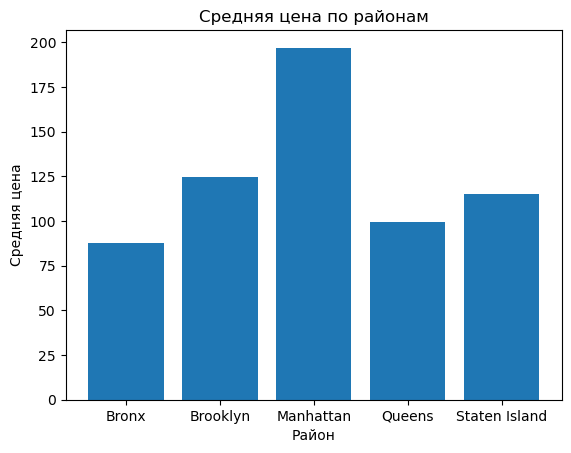

In [34]:
plt.figure()
plt.bar(price_by_neighbourhood_group.index, price_by_neighbourhood_group.values)

plt.title("Средняя цена по районам")
plt.xlabel("Район")
plt.ylabel("Средняя цена")
plt.xticks(rotation = 0)
plt.show()

In [ ]:
По данному графику можно сравнить средние цены между районами

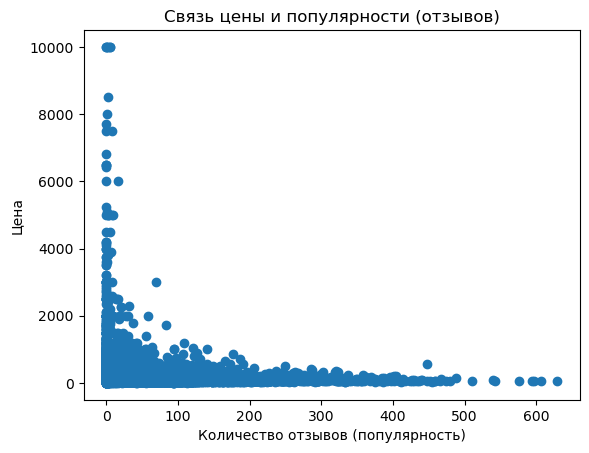

In [13]:
plt.figure()

plt.scatter(df['number_of_reviews'], df['price'],  alpha=0.5)

plt.title("Связь цены и популярности (отзывов)")
plt.xlabel("Количество отзывов (популярность)")
plt.ylabel("Цена")

plt.show()

In [ ]:
На диаграмме представлена зависимость между ценой жилья (price) и его популярностью. В данном графике популярность оценивается по количеству отзывов (number_of_reviews)

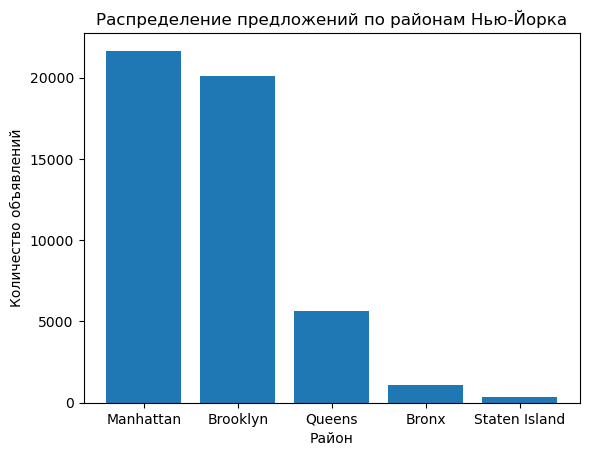

In [14]:
neighbourhood_counts = df["neighbourhood_group"].value_counts()

plt.figure()
plt.bar(neighbourhood_counts.index, neighbourhood_counts.values)

plt.title("Распределение предложений по районам Нью-Йорка")
plt.xlabel("Район")
plt.ylabel("Количество объявлений")

plt.show()

In [16]:
neighbourhood_counts

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [ ]:
По графику видно, сколько объявлений Airbnb расположено в каждом районе Нью-Йорка, и можно определить, какие районы доминируют на рынке

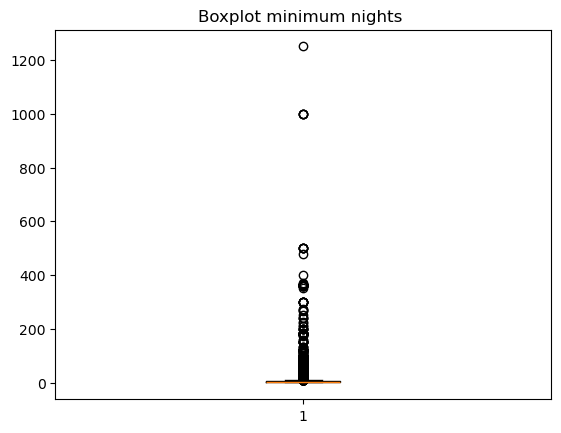

In [33]:
plt.figure() 
plt.boxplot(df["minimum_nights"]) 

plt.title("Boxplot minimum nights ")

plt.show() 

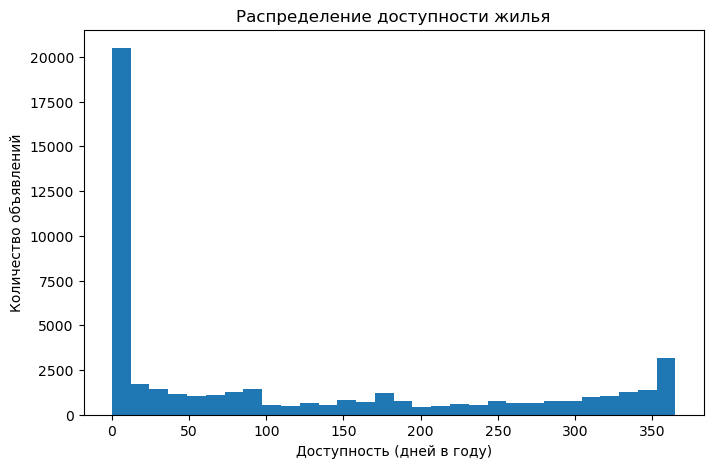

In [27]:
plt.figure(figsize=(8,5))

plt.hist(df['availability_365'], bins=30)

plt.title("Распределение доступности жилья")
plt.xlabel("Доступность (дней в году)")
plt.ylabel("Количество объявлений")

plt.show()

In [ ]:
На гистограмме представлено распределение переменной availability_365, которая показывает, сколько дней в году объект доступен для бронирования